# Phần 3 – Bình đẳng giới trong ASEAN: Khoảng cách giữa hai giới ở đâu?

## Động lực:
- Nhóm lựa chọn chủ đề này xuất phát từ những tranh luận, chiến dịch và làn sóng đấu tranh liên quan đến các phong trào nữ quyền trong thời gian gần đây.
- Từ bối cảnh đó, khi có cơ hội tiếp cận và phân tích dữ liệu trong Lab 2, nhóm đặt ra một câu hỏi trọng tâm: “Liệu có tồn tại sự bất công giữa nam và nữ trên thị trường lao động hay không?”
- Tuy nhiên, đây là một vấn đề rộng, chịu ảnh hưởng bởi nhiều yếu tố mà dữ liệu thống kê khó có thể phản ánh đầy đủ. Vì vậy, nhóm thu hẹp phạm vi nghiên cứu thành: “Liệu lao động nữ có đang được định giá đúng trên thị trường lao động hay không?”

## Các mục tiêu phân tích:

1. **Câu hỏi 1**: Sự tham gia của nữ trong thị trường lao động tại Việt Nam và các quốc gia trong khu vực diễn ra như thế nào? Có tồn tại sự chênh lệch đáng kể so với nam giới, hoặc có xu hướng thay đổi nào đáng chú ý trong giai đoạn 2000–2023 không?

2. **Câu hỏi 2**: Giáo dục đóng vai trò như thế nào đối với cả hai giới? Có tồn tại sự chênh lệch về trình độ học vấn giữa nam và nữ hay không?

3. **Câu hỏi 3**: Chất lượng việc làm và cơ hội thăng tiến của phụ nữ trong ASEAN phản ánh điều gì về bất bình đẳng giới? Liệu phụ nữ có đang bị “mắc kẹt” ở những vị trí dễ tổn thương, hay đã có cơ hội vươn lên trong nền kinh tế?

## Import thư viện và đọc dữ liệu

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Đường dẫn file dữ liệu (cùng thư mục với notebook)

data_path = "data.csv"

# Đọc file chính chứa các chỉ số WDI đã lọc
# Giá trị thiếu trong WDI thường được ký hiệu là ".." nên cần khai báo na_values
df = pd.read_csv(data_path, na_values=[".."])

print("Kích thước dữ liệu (hàng, cột):", df.shape)
df.head()

Kích thước dữ liệu (hàng, cột): (148, 28)


,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Viet Nam,VNM,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,69.974000,71.493000,70.833000,70.353000,70.098000,70.381000,70.727000,71.138000,71.550000,71.906000,71.731000,71.715000,71.983000,72.906000,73.059000,72.863000,72.530000,72.575000,72.897000,71.511000,69.095000,69.107000,69.878000,69.215000
1,Viet Nam,VNM,"Labor force participation rate, male (% of mal...",SL.TLF.CACT.MA.ZS,77.088000,78.609000,78.296000,78.157000,78.210000,78.453000,78.814000,79.286000,80.008000,80.566000,81.233000,81.466000,81.067000,81.962000,81.945000,82.417000,81.789000,82.197000,82.408000,82.088000,80.025000,78.712000,79.432000,78.201000
2,Viet Nam,VNM,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,7.787980,7.909690,8.266870,8.612940,NaN,13.112430,16.356440,18.705259,19.384121,20.712139,23.265679,25.413021,13.326013,23.931538,31.758766,29.436537,31.921503,27.444866,NaN,NaN,NaN,41.059099,45.370322,36.077468
3,Viet Nam,VNM,"School enrollment, tertiary, male (% gross)",SE.TER.ENRR.MA,10.674970,10.662680,10.821200,11.197440,NaN,18.590460,17.246309,19.195539,20.739670,22.318171,24.601287,26.327851,38.173576,27.297014,30.911545,30.006648,26.315797,24.494865,NaN,NaN,NaN,42.837902,44.145254,29.637136
4,Viet Nam,VNM,"Vulnerable employment, female (% of female emp...",SL.EMP.VULN.FE.ZS,78.626896,75.656329,76.710296,76.040663,72.989498,72.484119,71.978389,71.472529,70.245955,69.099961,69.624594,69.301928,69.060518,68.942591,68.089468,63.771349,62.247932,61.070384,59.316745,58.813215,58.555162,58.430084,58.415805,57.990049


## Khám phá tổng quan dataset


Trong phần này, chúng ta xem nhanh cấu trúc dữ liệu:

- Các cột định danh: `Country Name`, `Country Code`, `Series Name`, `Series Code`.

- Các cột năm: từ khoảng 2000 đến 2023, dạng `2000 [YR2000]`, ... chứa giá trị của chỉ số theo năm.



Các bước thực hiện:

1. Thống kê số lượng bản ghi và số lượng chỉ số (Series) trong dataset.

2. Kiểm tra dữ liệu thiếu (NA).

*Thông tin chung về dataframe*

In [78]:
print("\nCác cột của dữ liệu:")
print(df.columns.tolist())

print("\nSố nước trong dataset:", df["Country Name"].nunique())
print("Số series (chỉ số) khác nhau:", df["Series Code"].nunique())


Các cột của dữ liệu:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']

Số nước trong dataset: 13
Số series (chỉ số) khác nhau: 13


*Tỷ lệ giá trị thiếu theo cột*

In [79]:
year_cols = [c for c in df.columns if "[YR" in c]
print("\nSố lượng cột năm:", len(year_cols))

missing_ratio = df[year_cols].isna().mean().sort_values(ascending=False)
print("\nTỷ lệ thiếu trung bình ở các cột năm (top 10):")
print(missing_ratio.head(10))


Số lượng cột năm: 24

Tỷ lệ thiếu trung bình ở các cột năm (top 10):
2005 [YR2005]    0.310811
2004 [YR2004]    0.310811
2003 [YR2003]    0.290541
2001 [YR2001]    0.283784
2006 [YR2006]    0.283784
2002 [YR2002]    0.283784
2000 [YR2000]    0.270270
2008 [YR2008]    0.250000
2009 [YR2009]    0.209459
2007 [YR2007]    0.195946
dtype: float64


## Tiền xử lý
##### **Chuyển dữ liệu sang dạng "dài" (long format)**


Ở dạng gốc, mỗi năm là một cột. Để trực quan hóa và phân tích theo thời gian thuận tiện hơn, ta sẽ chuyển về dạng **long format** với các cột chính:

- `Country Name`, `Country Code`
- `Series Name`, `Series Code`
- `Year` (năm)
- `Value` (giá trị chỉ số)

*Chuyển sang long format*

In [80]:
#lọc col toàn nan
df = df.dropna(subset=year_cols, how="all").reset_index(drop=True)

id_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]

df_long = df.melt(id_vars=id_cols,
                  value_vars=year_cols,
                  var_name="Year",
                  value_name="Value")

*Rút trích năm từ chuỗi*
###### VD: "2000 [YR2000]" -> 2000

In [81]:
df_long["Year"] = pd.to_numeric(
    df_long["Year"].str.extract(r"(\d{4})", expand=False),
    errors="coerce"
)
df_long = df_long.dropna(subset=["Year"]).copy()
df_long["Year"] = df_long["Year"].astype(int)

*Lọc các nước ASEAN*

In [82]:
asean_countries = ["Viet Nam", "Singapore", "Malaysia", "Thailand", "Indonesia", "Philippines", "Brunei Darussalam", "Cambodia", "Lao PDR", "Myanmar", "Timor-Leste"]
df_asean = df_long[df_long["Country Name"].isin(asean_countries)].copy()

print("Kích thước dữ liệu long (ASEAN):", df_asean.shape)
df_asean.head()

Kích thước dữ liệu long (ASEAN): (3432, 6)


,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Viet Nam,VNM,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,2000,69.974000
1,Viet Nam,VNM,"Labor force participation rate, male (% of mal...",SL.TLF.CACT.MA.ZS,2000,77.088000
2,Viet Nam,VNM,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,2000,7.787980
3,Viet Nam,VNM,"School enrollment, tertiary, male (% gross)",SE.TER.ENRR.MA,2000,10.674970
4,Viet Nam,VNM,"Vulnerable employment, female (% of female emp...",SL.EMP.VULN.FE.ZS,2000,78.626896


## 5. **Câu hỏi 1**
### *Sự tham gia của nữ trong thị trường lao động tại Việt Nam và các quốc gia trong khu vực diễn ra như thế nào? Có tồn tại sự chênh lệch đáng kể so với nam giới, hoặc có xu hướng thay đổi nào đáng chú ý trong giai đoạn 2000–2023 không?*


Chỉ số (metrics) sử dụng:

- `SL.TLF.CACT.FE.ZS`: Labor force participation rate, female (% of female population 15+).

- `SL.TLF.CACT.MA.ZS`: Labor force participation rate, male (% of male population 15+).

Động lực:
- Quan niệm “đàn ông xây nhà, đàn bà xây tổ ấm” đã tồn tại từ lâu trong xã hội châu Á, đặc biệt là khu vực Đông Nam Á. Quan niệm này xuất phát một phần từ văn hóa, phong tục, và phần nào chịu ảnh hưởng của Nho giáo qua nhiều thế hệ.
- Do đó, trong bối cảnh xã hội hiện đại và đổi mới (2000–2023), nhóm muốn kiểm chứng liệu quan niệm này còn tồn tại hay không, và nếu có thì ở mức độ nào. Bước đầu tiên là phân tích các chỉ số liên quan đến sự tham gia thị trường lao động.
- Được tham gia vào thị trường lao động là một khẳng định gián tiếp cho việc được tự chủ tài chính, có khả năng tự chăm lo cho đời sống của bản thân và đóng góp ở mặt tài chính cho gia đình. Đây cũng là một yếu tố quan trọng trong việc đánh giá mức độ bình đẳng giới.

Mục tiêu:

- Phân tích xu hướng thay đổi tỷ lệ tham gia lực lượng lao động của nữ theo thời gian tại từng quốc gia.
- Đo lường khoảng cách giữa nam và nữ trong việc tham gia thị trường lao động tại thời điểm gần nhất trong bộ dữ liệu (năm 2023), từ đó so sánh giữa các quốc gia.

Câu hỏi mở rộng:
- Yếu tố dân số có ảnh hưởng như thế nào đến các kết quả quan sát được?
- Cần phân tích sâu hơn về xu hướng tham gia của nam giới để có cái nhìn toàn diện hơn về khoảng cách giới.

*Chỉ số (metrics) sử dụng*

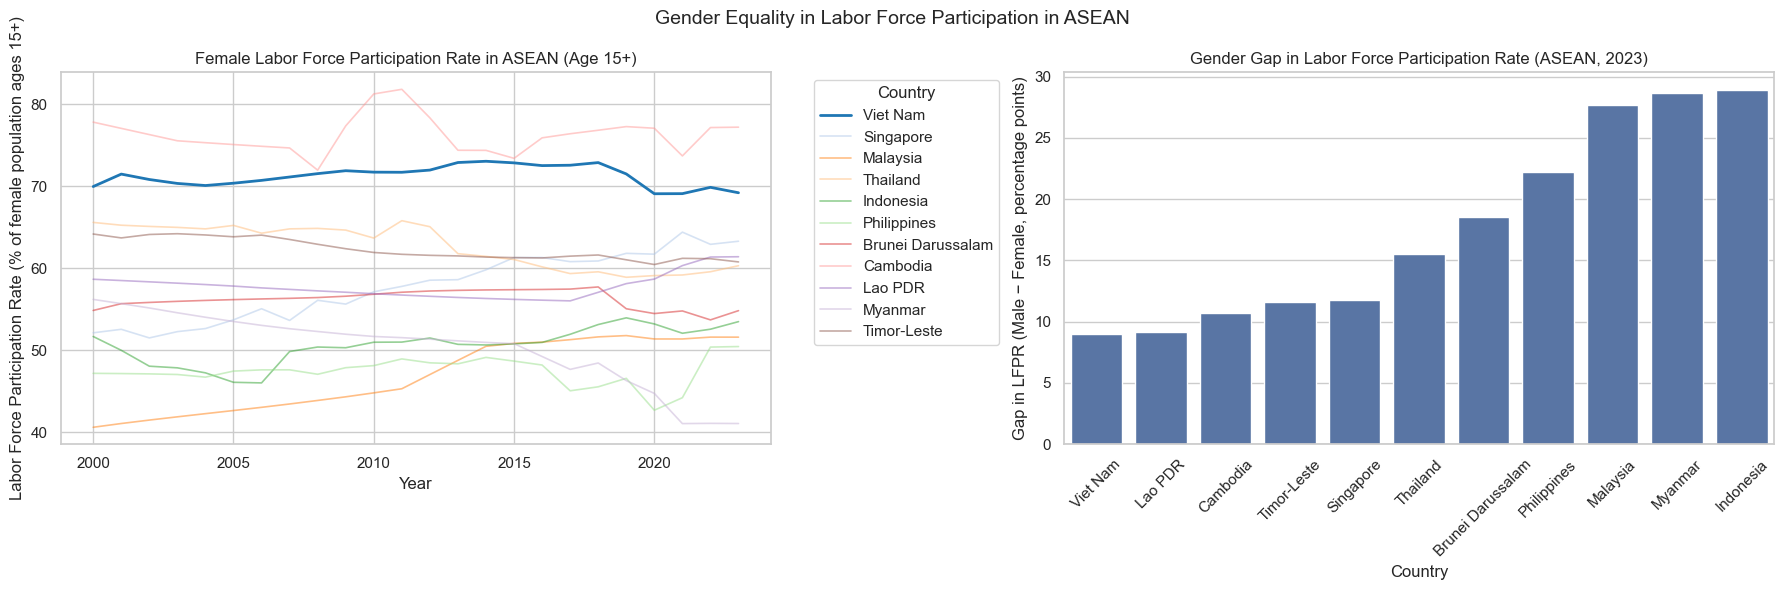

In [83]:
question1_section3 = {
    "female": "SL.TLF.CACT.FE.ZS",
    "male": "SL.TLF.CACT.MA.ZS",
}

df_q1_sect3 = df_asean[df_asean["Series Code"].isin(question1_section3.values())].copy()

lfpr_pivot = df_q1_sect3.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Code",
    values="Value"
)

lfpr_pivot = lfpr_pivot.rename(columns={
    question1_section3["female"]: "lfpr_female",
    question1_section3["male"]: "lfpr_male",
}).reset_index()

lfpr_pivot["gap_male_minus_female"] = lfpr_pivot["lfpr_male"] - lfpr_pivot["lfpr_female"]

#Chọn năm tham chiếu cho so sánh

year_ref_lfpr = 2023
if year_ref_lfpr not in lfpr_pivot["Year"].unique():
    year_ref_lfpr = int(lfpr_pivot["Year"].max())

latest_lfpr = lfpr_pivot[lfpr_pivot["Year"] == year_ref_lfpr].dropna(subset=["lfpr_female", "lfpr_male"])
latest_lfpr = latest_lfpr.sort_values("gap_male_minus_female")

#Biểu đồ đường LFPR của nữ theo thời gian cho từng nước
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# =======================
# (1) Line chart: LFPR nữ theo thời gian (ASEAN)
# =======================
palette = sns.color_palette("tab20", n_colors=len(asean_countries))

for i, country in enumerate(asean_countries):
    subset = lfpr_pivot[lfpr_pivot["Country Name"] == country]
    if subset.empty:
        continue
#color="lightgray"
    if country == 'Viet Nam':
        axes[0].plot(
            subset["Year"], subset["lfpr_female"],
            label=country, color=palette[i], linewidth=2
        )
    else:
        axes[0].plot(
            subset["Year"], subset["lfpr_female"],
            label=country, linewidth=1.2, color=palette[i], alpha=0.5
        )

axes[0].set_title("Female Labor Force Participation Rate in ASEAN (Age 15+)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Labor Force Participation Rate (% of female population ages 15+)")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Country")


# =======================
# (2) Bar chart: gender gap
# =======================
sns.barplot(
    data=latest_lfpr,
    x="Country Name",
    y="gap_male_minus_female",
    ax=axes[1]
)

axes[1].set_title(
    f"Gender Gap in Labor Force Participation Rate (ASEAN, {year_ref_lfpr})"
)
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Gap in LFPR (Male − Female, percentage points)")
axes[1].tick_params(axis='x', rotation=45)

axes[1].axhline(0, color="black", linewidth=0.8)
fig.suptitle(
    "Gender Equality in Labor Force Participation in ASEAN",
    fontsize=14
)

# =======================
# Layout chung
# =======================
plt.tight_layout()
plt.show()

### Nhận xét & lý do chọn biểu đồ cho Câu hỏi 1

**Lý do chọn biểu đồ:**

- Biểu đồ đường nhiều series giúp so sánh xu hướng tỷ lệ tham gia lực lượng lao động của nữ (LFPR nữ) theo thời gian giữa các nước ASEAN và làm nổi bật Việt Nam (màu/nét đậm hơn).

- Trục thời gian liên tục 2000–2023 cho phép quan sát các cú sốc (ví dụ giai đoạn 2015–2020, 2020–2023) thay vì chỉ nhìn một năm đơn lẻ.



**Insight chính từ biểu đồ đường (LFPR nữ theo thời gian):**

- Việt Nam nằm trong nhóm nước có tỷ lệ tham gia lực lượng lao động của nữ cao và khá ổn định, quanh mức xấp xỉ ~70% trong gần như toàn bộ giai đoạn; so với ASEAN, Việt Nam chỉ thấp hơn một vài nước như Cambodia và thường cao hơn nhiều nước còn lại.

- Đường của Việt Nam tương đối “phẳng”, chỉ giảm nhẹ ở giai đoạn 2015–2020, cho thấy các cú sốc kinh tế – xã hội có tác động nhưng không khiến phụ nữ Việt Nam rời bỏ thị trường lao động một cách ồ ạt.

- Một số nước như Singapore, Malaysia có xu hướng tăng dần LFPR nữ theo thời gian, phản ánh quá trình hiện đại hóa và mở rộng cơ hội cho phụ nữ trong thị trường lao động.

- Ngược lại, Myanmar có xu hướng giảm rõ rệt, đặc biệt sau 2015, cho thấy bối cảnh chính trị – kinh tế bất ổn có thể tác động tiêu cực đến cơ hội lao động của nữ.

- Nhìn tổng thể, ASEAN đang chuyển dịch theo hướng tỷ lệ tham gia của nữ ngày càng tiệm cận một “mặt bằng mới” cao hơn, trong đó Việt Nam là một ví dụ nổi bật về mức độ tham gia cao và ổn định.

### Insight từ biểu đồ cột khoảng cách giới và kết luận Câu hỏi 1



**Lý do chọn biểu đồ cột:**

- Biểu đồ cột với trục tung là khoảng cách `LFPR nam − nữ` tại năm tham chiếu giúp nhìn rất nhanh nước nào còn khoảng cách giới lớn/nhỏ trong một thời điểm cụ thể.

- Đường 0 trên trục tung đóng vai trò mốc trực quan: cột càng cao (dương) càng cho thấy bất bình đẳng trong mức độ tham gia thị trường lao động nghiêng về phía nam giới.



**Insight chính từ biểu đồ cột:**

- Ở hầu hết các nước ASEAN, tỷ lệ tham gia lực lượng lao động của nam vẫn cao hơn nữ (các cột dương), nghĩa là bất bình đẳng về mức độ tham gia vẫn tồn tại.

- Việt Nam nằm trong nhóm nước có khoảng cách giới ở mức trung bình–thấp so với khu vực: nữ tham gia thị trường lao động với tỷ lệ khá tiệm cận nam, không bị bỏ xa như ở một số nước khác.

- Một vài nước có khoảng cách giới rất lớn cho thấy dù phụ nữ có thể được khuyến khích học tập, họ vẫn chưa thực sự hiện diện trong lực lượng lao động với mức tương xứng so với nam.



**Kết luận cho Câu hỏi 1 (Việt Nam so với ASEAN):**

- Về cơ hội **tham gia** thị trường lao động, phụ nữ Việt Nam đang ở vị thế tương đối tích cực so với mặt bằng ASEAN: tỷ lệ tham gia cao, khoảng cách với nam không quá lớn.

- Tuy nhiên, việc nam vẫn duy trì tỷ lệ tham gia cao hơn cho thấy bình đẳng giới trong **quyền được có mặt trên thị trường lao động** mới chỉ tiến gần tới mục tiêu, chưa hoàn toàn đạt được. Nói cách khác, Việt Nam đã đi khá nhanh, nhưng bức tranh chung của ASEAN vẫn còn bất cân xứng.

## 6. **Câu hỏi 2**
### *Giáo dục đóng vai trò như thế nào đối với cả hai giới? Có tồn tại sự chênh lệch về trình độ học vấn giữa nam và nữ hay không?*



Chỉ số (metrics) sử dụng:

- `SE.TER.ENRR.FE`: School enrollment, tertiary, female (% gross).
- `SE.TER.ENRR.MA`: School enrollment, tertiary, male (% gross).

Động lực:
- Sau khi phân tích sự tham gia vào thị trường lao động của hai giới, bước tiếp theo là đi sâu vào các yếu tố nền tảng có thể ảnh hưởng đến sự tham gia này, trong đó giáo dục là yếu tố quan trọng.
- Thị trường lao động có nhiều phân tầng và thường gắn chặt với trình độ học vấn, vì vậy cần xem xét vị trí của nữ giới trong hệ thống giáo dục tại các quốc gia ASEAN.
- Từ đó, đặt ra câu hỏi liệu trình độ học vấn có đang trở thành rào cản đối với sự tham gia của phụ nữ vào thị trường lao động hay không.

Mục tiêu: (khoảng năm)
- Phân tích tỷ lệ hoàn thành bậc trung học của nam và nữ theo thời gian.
- Theo dõi xu hướng tỷ lệ nhập học bậc đại học của hai giới theo thời gian để đánh giá mức độ chênh lệch.

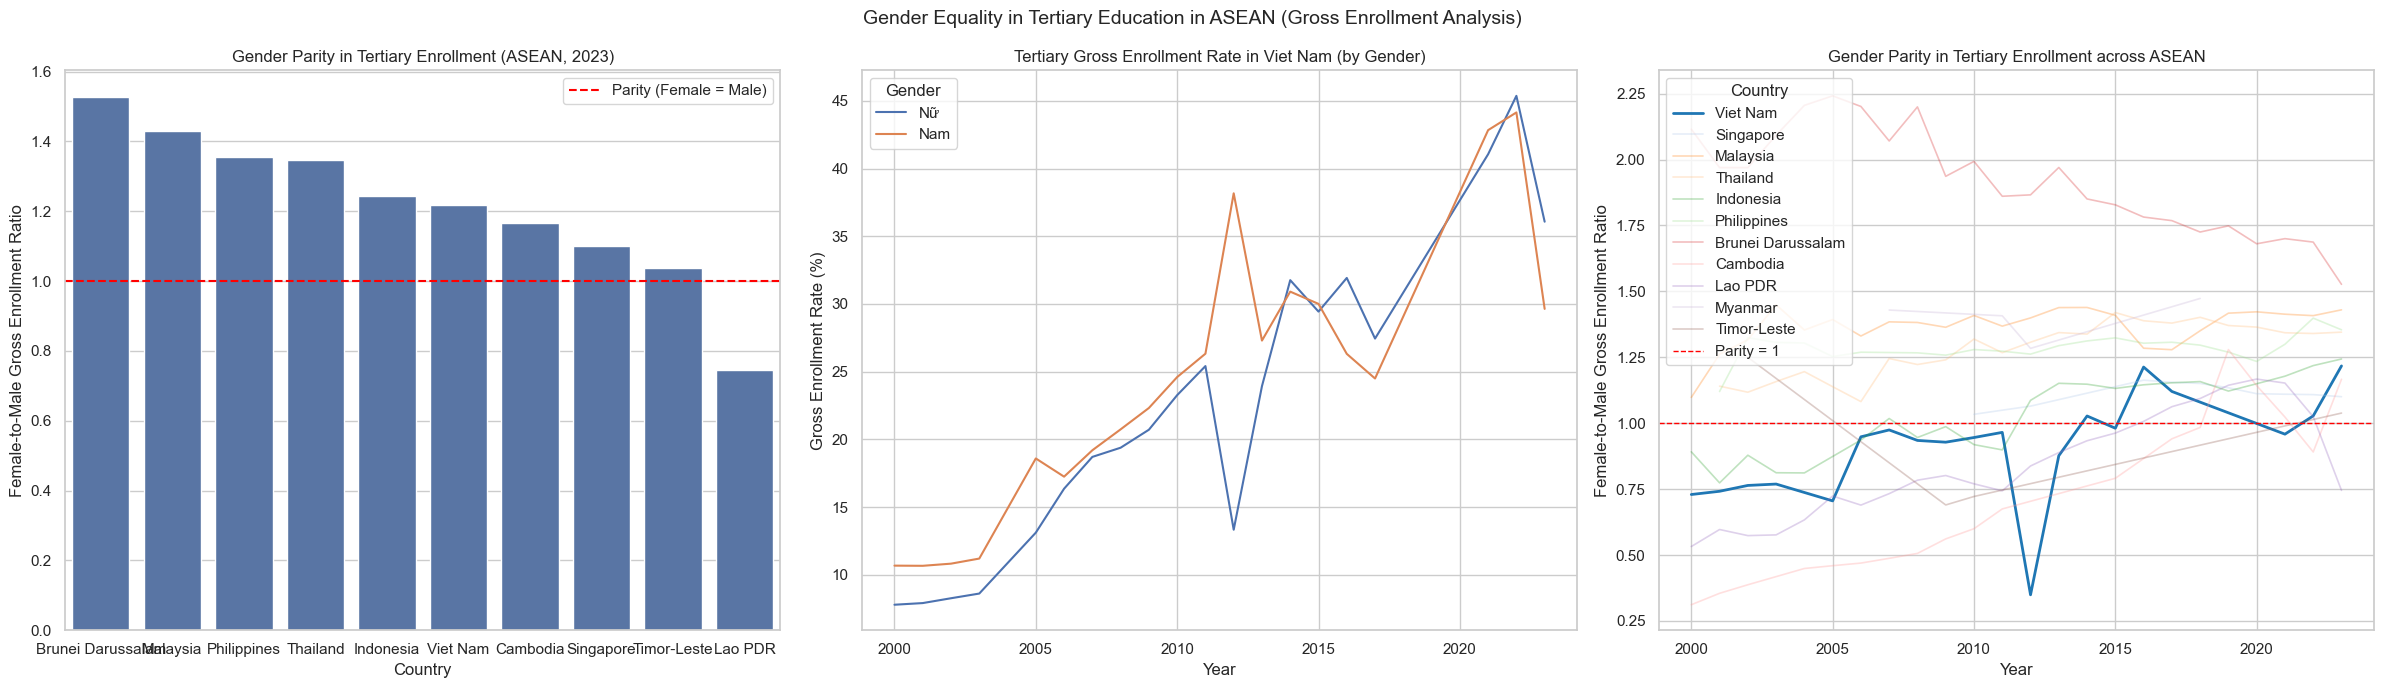

In [84]:
question2_section3 = {
    "female": "SE.TER.ENRR.FE",
    "male": "SE.TER.ENRR.MA",
}

#tạo df
df_q2_sect3 = df_asean[df_asean["Series Code"].isin(question2_section3.values())].copy()

ter_pivot = df_q2_sect3.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Code",
    values="Value"
)

ter_pivot = ter_pivot.rename(columns={
    question2_section3["female"]: "ter_female",
    question2_section3["male"]: "ter_male",
}).reset_index()

# thay thành khoảng năm gần nhất có dữ liệu

ter_pivot["female_to_male"] = ter_pivot["ter_female"] / ter_pivot["ter_male"]

# Năm gần nhất có dữ liệu tertiary
#latest_year_ter = int(ter_pivot["Year"].max())
latest_year_ter = 2023

latest_ter = ter_pivot[ter_pivot["Year"] == latest_year_ter].dropna(subset=["ter_female", "ter_male"])
latest_ter.sort_values("female_to_male", ascending=False, inplace=True)


#Biểu đồ parity nữ/nam theo quốc gia cho năm 2023
# Tạo figure gồm 3 subplot (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# =======================
# (1) Bar chart: parity 2023
# =======================
sns.barplot(
    data=latest_ter,
    x="Country Name",
    y="female_to_male",
    ax=axes[0]
)

axes[0].set_title(f"Gender Parity in Tertiary Enrollment (ASEAN, {latest_year_ter})")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Female-to-Male Gross Enrollment Ratio")
axes[0].axhline(1, color="red", linestyle="--", label="Parity (Female = Male)")
axes[0].legend()


# =======================
# (2) Line chart: Việt Nam theo thời gian
# =======================
vn_ter = ter_pivot[
    ter_pivot["Country Name"] == "Viet Nam"
].dropna(subset=["ter_female", "ter_male"])

sns.lineplot(data=vn_ter, x="Year", y="ter_female", label="Nữ", ax=axes[1])
sns.lineplot(data=vn_ter, x="Year", y="ter_male", label="Nam", ax=axes[1])

axes[1].set_title("Tertiary Gross Enrollment Rate in Viet Nam (by Gender)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Gross Enrollment Rate (%)")
axes[1].legend(title="Gender")


# =======================
# (3) Line chart: ASEAN female/male ratio
# =======================
for i, country in enumerate(asean_countries):
    subset = ter_pivot[
        ter_pivot["Country Name"] == country
    ].dropna(subset=["female_to_male"])
    
    if subset.empty:
        continue
    
    if country == 'Viet Nam':
        axes[2].plot(
            subset["Year"], subset["female_to_male"],
            label=country, color=palette[i], linewidth=2
        )
    else:
        axes[2].plot(
            subset["Year"], subset["female_to_male"], label=country,
            color=palette[i], linewidth=1.2, alpha=0.3
        )

axes[2].axhline(1, color="red", linestyle="--", linewidth=1, label="Parity = 1")
axes[2].set_title("Gender Parity in Tertiary Enrollment across ASEAN")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Female-to-Male Gross Enrollment Ratio")
axes[2].legend(title="Country")

# =======================
# Layout chung
# =======================
fig.suptitle(
    "Gender Equality in Tertiary Education in ASEAN (Gross Enrollment Analysis)",
    fontsize=14
)
plt.tight_layout()
plt.show()


### Nhận xét, insight và kết luận cho Câu hỏi 2



**Lý do chọn bộ 3 biểu đồ:**

- Biểu đồ cột `female_to_male` theo quốc gia tại năm gần nhất giúp so sánh nhanh mức độ cân bằng (hay vượt trội) của nữ so với nam trong tuyển sinh bậc đại học giữa các nước ASEAN.

- Biểu đồ đường cho riêng Việt Nam theo thời gian cho phép theo dõi quỹ đạo phát triển giáo dục đại học của hai giới, xem có giai đoạn nào nữ bị “bỏ lại phía sau” hay không.

- Biểu đồ đường tỷ lệ nữ/nam của cả ASEAN cho thấy Việt Nam đứng ở đâu trong bức tranh chung, và nước nào đang đi trước/đi sau về bình đẳng giới trong giáo dục đại học.



**Insight chính (Việt Nam vs ASEAN):**

- Ở năm tham chiếu, quan sát biểu đồ cho thấy phần lớn nước ASEAN – trong đó có Việt Nam – đều có tỷ lệ tuyển sinh bậc đại học của nữ **xấp xỉ hoặc cao hơn** nam (`female_to_male` ≳ 1). Điều này cho thấy cánh cửa vào đại học đối với phụ nữ không còn bị giới hạn mà thậm chí ở nhiều nơi còn rộng mở hơn cho nữ.

- Đối với Việt Nam, hai đường `ter_female` và `ter_male` theo thời gian đi khá sát nhau, trong nhiều năm nữ ngang bằng hoặc nhỉnh hơn nam. Không có giai đoạn dài mà nữ liên tục thấp hơn nam một khoảng lớn.

- Trong biểu đồ tỷ lệ nữ/nam toàn ASEAN, Việt Nam thuộc nhóm nước có mức độ cân bằng tương đối tốt.


**Kết luận cho Câu hỏi 2:**

- Ở cấp độ giáo dục, đặc biệt là bậc đại học, Việt Nam không thua kém ASEAN về cơ hội cho phụ nữ; ngược lại, Việt Nam đang đứng trong nhóm nước có mức độ bình đẳng giới tương đối tích cực.

- Điều này gợi ý rằng nếu lao động nữ trên thị trường lao động Việt Nam vẫn bị “định giá thấp” so với nam thì nguyên nhân **không nằm ở chỗ phụ nữ thiếu cơ hội học đại học**, mà nhiều khả năng nằm ở cấu trúc thị trường lao động, định kiến giới hoặc cách doanh nghiệp sử dụng và trả lương cho lao động nữ.

## **Câu hỏi 3**
### *Chất lượng việc làm và cơ hội thăng tiến của phụ nữ trong ASEAN phản ánh điều gì về bất bình đẳng giới? Liệu phụ nữ có đang bị “mắc kẹt” ở những vị trí dễ tổn thương, hay đã có cơ hội vươn lên trong nền kinh tế?*



Chỉ số (metrics) sử dụng:

- `SL.UEM.NEET.FE.ZS`, `SL.UEM.NEET.MA.ZS`: Share of youth not in education, employment or training (NEET), nữ/nam.

- `SL.EMP.SMGT.FE.ZS`: Female share of employment in senior and middle management (%).

- `NY.GDP.PCAP.KD`: GDP per capita (constant 2015 US$).

Động lực:
- Sau khi xem xét mức độ tham gia thị trường lao động và yếu tố giáo dục, bước tiếp theo là đánh giá chất lượng việc làm và cơ hội phát triển nghề nghiệp của phụ nữ.
- Không chỉ dừng lại ở việc “có việc làm”, điều quan trọng là phụ nữ đang làm việc ở đâu trong chuỗi giá trị lao động: ở các vị trí ổn định, có cơ hội thăng tiến, hay chủ yếu ở những công việc dễ bị tổn thương?
- Đồng thời, cần xem xét liệu sự phát triển kinh tế của một quốc gia có đi kèm với việc cải thiện vị thế của phụ nữ trong thị trường lao động hay không.



Mục tiêu:

- So sánh tỷ lệ NEET giữa nữ và nam để đánh giá liệu phụ nữ trẻ có đối mặt với nguy cơ “không học – không làm” cao hơn hay không.
- Phân tích tỷ lệ phụ nữ trong các vị trí quản lý và đặt trong tương quan với mức GDP bình quân đầu người.
- Từ đó, rút ra nhận định về mô hình phát triển của các quốc gia ASEAN: phụ nữ chỉ tham gia lao động ở các vị trí thấp, hay thực sự có cơ hội thăng tiến và nắm giữ vai trò quan trọng.

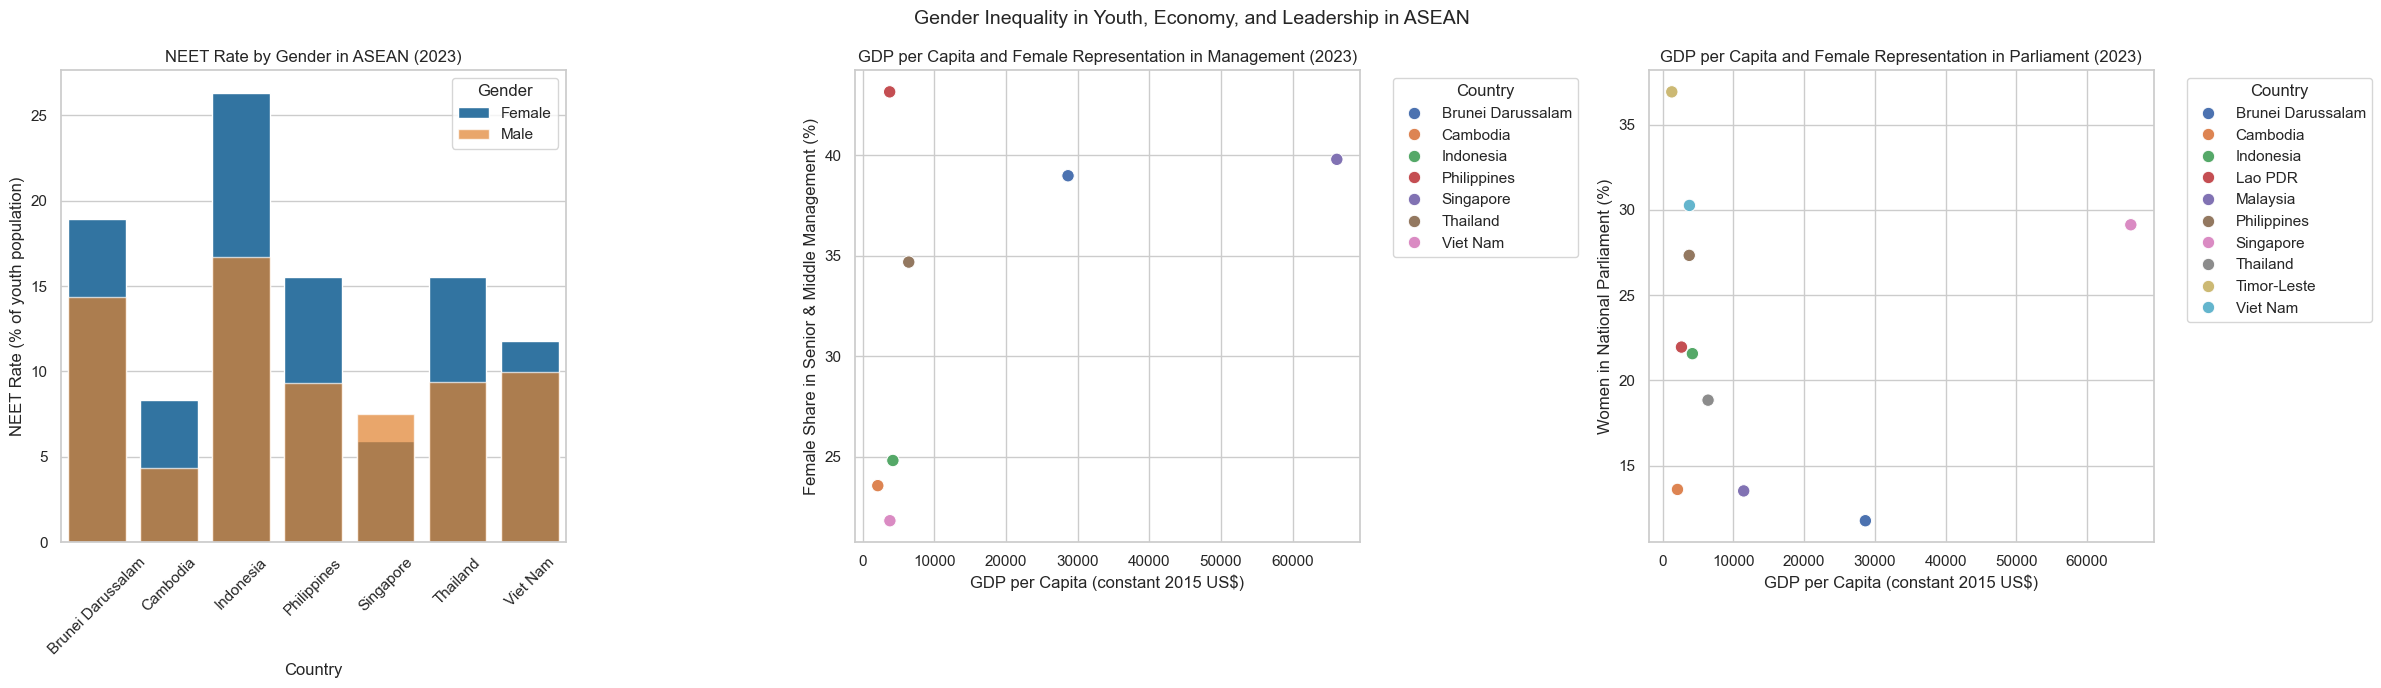

In [85]:
year_ref = 2023
if year_ref not in df_asean["Year"].unique():
    year_ref = int(df_asean["Year"].max())

question3_section3 = {
    "neet_female": "SL.UEM.NEET.FE.ZS",
    "neet_male": "SL.UEM.NEET.MA.ZS",
}

mgmt_code = "SL.EMP.SMGT.FE.ZS"  # nữ trong vị trí quản lý
parl_code = "SG.GEN.PARL.ZS"  # Tỷ lệ nữ trong quốc hội
gdp_pc_code = "NY.GDP.PCAP.KD"   # GDP per capita (constant 2015 US$)

subset = df_asean[df_asean["Year"] == year_ref].copy()
neet = subset[subset["Series Code"].isin(question3_section3.values())]

neet_pivot = neet.pivot_table(
    index="Country Name",
    columns="Series Code",
    values="Value"
)

neet_pivot = neet_pivot.rename(columns={
    question3_section3["neet_female"]: "neet_female",
    question3_section3["neet_male"]: "neet_male",
})

mgmt = subset[subset["Series Code"] == mgmt_code].set_index("Country Name")["Value"].rename("female_mgmt")
gdp_pc = subset[subset["Series Code"] == gdp_pc_code].set_index("Country Name")["Value"].rename("gdp_per_capita")
parl = subset[subset["Series Code"] == parl_code].set_index("Country Name")["Value"].rename("female_parl")

# Gộp tất cả vào một bảng
summary = neet_pivot.join(mgmt, how="outer").join(gdp_pc, how="outer").join(parl, how="outer")

# Chênh lệch NEET nữ - nam
summary["neet_gap_female_minus_male"] = summary["neet_female"] - summary["neet_male"]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# =======================
# (1) Bar chart: NEET by gender
# =======================
neet_plot = summary.dropna(subset=["neet_female", "neet_male"]).reset_index()

sns.barplot(
    data=neet_plot,
    x="Country Name",
    y="neet_female",
    color="tab:blue",
    label="Female",
    ax=axes[0]
)

sns.barplot(
    data=neet_plot,
    x="Country Name",
    y="neet_male",
    color="tab:orange",
    label="Male",
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title(f"NEET Rate by Gender in ASEAN ({year_ref})")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("NEET Rate (% of youth population)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Gender")


# =======================
# (2) Scatter: GDP vs female management
# =======================
mgmt_plot = summary.dropna(subset=["female_mgmt", "gdp_per_capita"]).reset_index()

sns.scatterplot(
    data=mgmt_plot,
    x="gdp_per_capita",
    y="female_mgmt",
    hue="Country Name",
    s=80,
    ax=axes[1]
)

axes[1].set_title(f"GDP per Capita and Female Representation in Management ({year_ref})")
axes[1].set_xlabel("GDP per Capita (constant 2015 US$)")
axes[1].set_ylabel("Female Share in Senior & Middle Management (%)")
axes[1].legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")


# =======================
# (3) Scatter: GDP vs female parliament
# =======================
parl_plot = summary.dropna(subset=["female_parl", "gdp_per_capita"]).reset_index()

sns.scatterplot(
    data=parl_plot,
    x="gdp_per_capita",
    y="female_parl",
    hue="Country Name",
    s=80,
    ax=axes[2]
)

axes[2].set_title(f"GDP per Capita and Female Representation in Parliament ({year_ref})")
axes[2].set_xlabel("GDP per Capita (constant 2015 US$)")
axes[2].set_ylabel("Women in National Parliament (%)")
axes[2].legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")


# =======================
# Suptitle + layout
# =======================
fig.suptitle(
    "Gender Inequality in Youth, Economy, and Leadership in ASEAN",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Nhận xét, insight và kết luận cho Câu hỏi 3



**Lý do chọn các biểu đồ:**

- Biểu đồ cột NEET theo giới cho từng quốc gia giúp nhìn rõ liệu thanh niên nữ có chịu rủi ro “không học – không làm – không được đào tạo” cao hơn nam hay không.

- Hai biểu đồ scatter giữa GDP bình quân đầu người với tỷ lệ nữ trong quản lý và trong quốc hội giúp kiểm tra xem phát triển kinh tế có đi kèm với việc nâng cao vị thế của phụ nữ trong các vị trí quyền lực hay không, đồng thời đặt Việt Nam vào bức tranh đó.



**Insight chính (Việt Nam vs ASEAN):**

- Ở nhiều nước ASEAN, NEET của nữ cao hơn nam, phản ánh việc phụ nữ trẻ dễ bị “rơi khỏi” cả hệ thống giáo dục lẫn thị trường lao động hơn. Việt Nam không nằm trong nhóm tệ nhất, nhưng NEET nữ vẫn có xu hướng nhỉnh hơn NEET nam, cho thấy rào cản đối với phụ nữ trẻ vẫn tồn tại (gánh nặng chăm sóc gia đình, chuẩn mực giới,…).

- Trên biểu đồ GDP – tỷ lệ nữ trong quản lý, một số nước có GDP cao nhưng tỷ lệ nữ giữ vị trí quản lý chưa thật sự nổi bật; ngược lại, Việt Nam – với mức GDP trung bình trong ASEAN – lại có tỷ lệ nữ trong quản lý ở mức tương đối tích cực so với khu vực. Điều này cho thấy phụ nữ Việt Nam không chỉ tham gia lao động mà còn có cơ hội bước vào các vị trí trung – cao.

- Với tỷ lệ nữ trong quốc hội, Việt Nam tiếp tục nằm trong nhóm nước có đại diện nữ khá cao so với mức thu nhập, thể hiện nỗ lực thể chế trong việc đưa phụ nữ vào các vị trí ra quyết định chính sách.



**Kết luận cho Câu hỏi 3:**

- Về **chất lượng việc làm và cơ hội thăng tiến**, phụ nữ Việt Nam nhìn chung không bị “mắc kẹt” ở mức tệ nhất trong ASEAN; họ hiện diện trong quản lý và chính trị ở mức tương đối tốt so với mặt bằng khu vực.

- Tuy nhiên, chênh lệch NEET nữ–nam và thực tế là tỷ lệ nữ trong quản lý và quốc hội vẫn thấp hơn 50% cho thấy trần kính vẫn tồn tại: phụ nữ Việt Nam đã “bước được vào phòng”, nhưng chưa thực sự chiếm một nửa số ghế.

- Điều này hàm ý bất bình đẳng giới ở Việt Nam đang dịch chuyển từ câu chuyện **“có được tham gia hay không”** sang câu chuyện **“được tham gia ở vị trí nào và với điều kiện ra sao”**.

## Kết luận chung: Việt Nam trong bức tranh bình đẳng giới ASEAN



**Quay lại câu hỏi ban đầu:** “Liệu lao động nữ có đang được định giá đúng trên thị trường lao động hay không?”, đặc biệt là trong trường hợp Việt Nam so với ASEAN.



Từ ba nhóm phân tích, có thể tóm lược như sau:



1. **Mức độ tham gia thị trường lao động (Câu hỏi 1)**  

   - Việt Nam thuộc nhóm nước có tỷ lệ tham gia lực lượng lao động của nữ cao, khoảng cách với nam không quá lớn.  

   - So với ASEAN, phụ nữ Việt Nam **không bị loại khỏi thị trường lao động**, thậm chí hiện diện khá tích cực.



2. **Giáo dục và trình độ học vấn (Câu hỏi 2)**  

   - Cơ hội vào đại học của nữ Việt Nam ít nhất ngang bằng, nhiều khi nhỉnh hơn nam và tương đối tốt so với khu vực.  

   - Điều này cho thấy **trình độ học vấn không phải là “nút thắt” khiến lao động nữ bị định giá thấp**, tức là phụ nữ đi làm không hề kém cạnh về vốn nhân lực so với nam.



3. **Chất lượng việc làm và vị thế trong hệ thống quyền lực (Câu hỏi 3)**  

   - NEET nữ vẫn cao hơn NEET nam, và tỷ lệ nữ trong quản lý/quốc hội còn thấp hơn 50%, cho thấy phụ nữ vẫn chịu rủi ro bị gạt ra ngoài các cơ hội tốt.  

   - Dù vậy, so với nhiều nước ASEAN có thu nhập tương đương, Việt Nam đang làm **khá tốt** trong việc đưa phụ nữ vào các vị trí quản lý và chính trị.



**Vậy câu hỏi ban đầu được giải quyết tới đâu?**

- Ở góc độ **tiếp cận cơ hội** (được đi học, được tham gia thị trường lao động, có mặt trong các vị trí quản lý và chính trị), dữ liệu cho thấy phụ nữ Việt Nam đang ở vị thế tương đối tích cực trong ASEAN. Điều này là dấu hiệu rằng xã hội và thể chế đã và đang nỗ lực thu hẹp khoảng cách giới.

- Tuy nhiên, dữ liệu hiện có **chưa cho phép khẳng định dứt khoát** rằng lao động nữ đã được “định giá đúng” về mặt tiền lương, đãi ngộ và điều kiện làm việc, vì chúng ta chưa quan sát trực tiếp mức lương, thời giờ làm việc, loại hợp đồng hay phân tầng nghề nghiệp chi tiết.

- Nói cách khác, phân tích trong Lab này mới trả lời được một phần câu hỏi ở cấp độ **“cơ hội” và “hiện diện”**; để kết luận đầy đủ về việc lao động nữ có bị định giá thấp hay không, cần thêm dữ liệu vi mô về lương, nghề nghiệp, thời gian làm việc, gánh nặng chăm sóc không lương,…



Dù vậy, từ ba mục tiêu phân tích (ba câu hỏi trong quá trình tìm hiểu), chúng ta có thể thấy một bức tranh ASEAN – và Việt Nam nói riêng – đang từng bước tiến lên, tiên tiến và cởi mở hơn trong thị trường lao động và trong hệ thống giáo dục, từng bước phá vỡ những định kiến và những “xiềng xích vô hình” đã níu chân người phụ nữ trong quá khứ.